<a href="https://colab.research.google.com/github/VETTOORLIJO/DS_VettoorLijo/blob/master/ML_Assignment_2_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

● Load the California Housing dataset using the fetch_california_housing function
from sklearn.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler


Convert the dataset into a pandas DataFrame for easier handling. Handle
missing values (if any) and perform necessary feature scaling (e.g.,
standardization).



---



In [4]:
housing_data = fetch_california_housing()
print(housing_data.keys())

dict_keys(['data', 'target', 'frame', 'target_names', 'feature_names', 'DESCR'])


In [5]:
print(housing_data.data)

[[   8.3252       41.            6.98412698 ...    2.55555556
    37.88       -122.23      ]
 [   8.3014       21.            6.23813708 ...    2.10984183
    37.86       -122.22      ]
 [   7.2574       52.            8.28813559 ...    2.80225989
    37.85       -122.24      ]
 ...
 [   1.7          17.            5.20554273 ...    2.3256351
    39.43       -121.22      ]
 [   1.8672       18.            5.32951289 ...    2.12320917
    39.43       -121.32      ]
 [   2.3886       16.            5.25471698 ...    2.61698113
    39.37       -121.24      ]]


In [6]:
print(housing_data.target)

[4.526 3.585 3.521 ... 0.923 0.847 0.894]


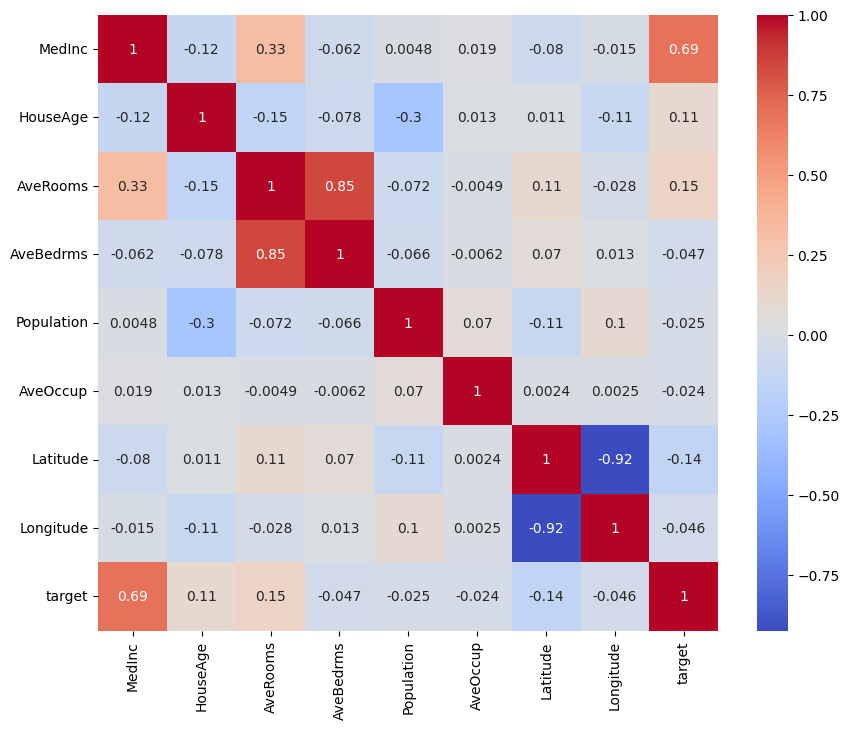

In [7]:
housing_df = pd.DataFrame(housing_data.data,columns=housing_data.feature_names)
housing_df['target'] = housing_data.target
plt.figure(figsize=(10,8))
sns.heatmap(housing_df.corr(),annot=True,cmap="coolwarm")
plt.show()

***Correlation Analysis: MedInc has Very Strong Correlation***

***Initial Inspection (Duplicates, Nulls, Zeros)***


In [8]:
print(housing_df[housing_df.duplicated()])

Empty DataFrame
Columns: [MedInc, HouseAge, AveRooms, AveBedrms, Population, AveOccup, Latitude, Longitude, target]
Index: []


In [9]:
(housing_df==0).sum()

,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
target,0


In [10]:
housing_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   target      20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


***Exploratory Data Analysis (EDA) and Feature Selection***

In [11]:
housing_df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


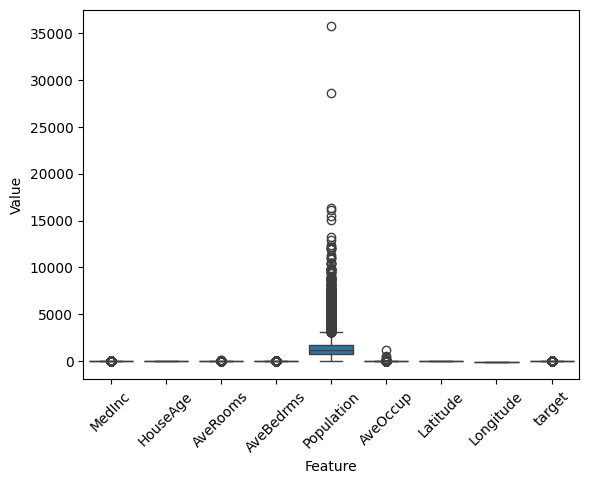

In [12]:
sns.boxplot(data=housing_df.melt(var_name="Feature",value_name="Value"),x="Feature",y="Value")

plt.xticks(rotation=45)
plt.show()

***Outlier Detection and Removal***

In [13]:
# percental method

# P10 = housing_df.quantile(0.10)
# P90 = housing_df.quantile(0.90)

# within_bounds = (((housing_df >= P10) &(housing_df <= P90))).all(axis=1)
# no_outliers_df = housing_df[within_bounds]

# print("Original shape:", housing_df.shape)
# print("No outliers shape:", no_outliers_df.shape)
# sns.boxplot(data=no_outliers_df.melt(var_name="Feature",value_name="Value"),
#     x="Feature",y="Value")
# plt.xticks(rotation=45)
# plt.show()

No outliers shape: (16312, 9)


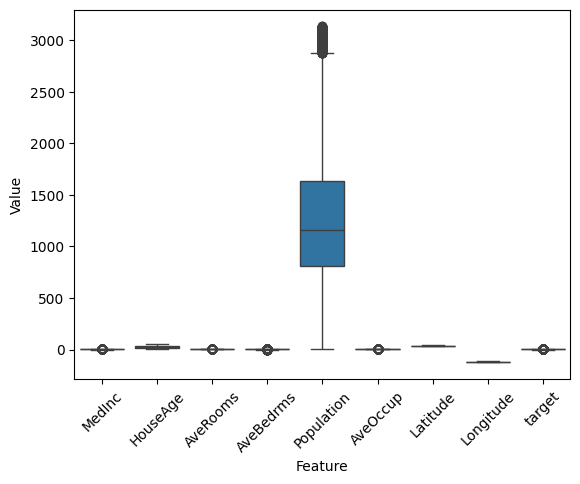

In [14]:
#IQR method remove outlier
Q1 = housing_df.quantile(0.25)
Q3 = housing_df.quantile(0.75)
IQR = Q3 - Q1
within_bounds = ((housing_df >= (Q1 - 1.5 * IQR)) & (housing_df <= (Q3 + 1.5 * IQR))).all(axis=1)
no_outliers_df = housing_df[within_bounds]
print("No outliers shape:", no_outliers_df.shape)
sns.boxplot(data=no_outliers_df.melt(var_name="Feature",value_name="Value"), x="Feature", y="Value")
plt.xticks(rotation=45)
plt.show()

In [15]:
X=no_outliers_df[["MedInc"]]
y=no_outliers_df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
#scale only MedInc and target
scaler= StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [16]:
print(X_train_scaled.mean())
print(X_train_scaled.std())

2.3849928597051414e-16
0.9999999999999999


Explain the preprocessing steps you performed and justify why they are necessary for this dataset.


*   Data Loading and Initial Inspection
*   Exploratory Data Analysis (EDA) and Feature Selection  [Initial Inspection (Duplicates, Nulls, Zeros), Correlation Analysis]
*   Outlier Detection and Removal:




In [17]:
# Performed correlation analysis to identify the features most strongly related to the target variable.
# Checked the dataset for duplicate values.
# Verified the dataset for missing (null) values.
# Checked for zero values in the dataset.
# Used box plots to identify potential outliers.
# Applied the IQR (Interquartile Range) method to remove outliers.
# Re-examined the box plots to confirm that outliers were handled appropriately.
# Split the data into training and testing sets.
# Applied StandardScaler to standardise the feature values.
# Verified the scaling process by checking that the feature means were close to 0 and the standard deviations were 1.
# Prepared the cleaned and scaled dataset for Linear Regression modelling.

# **Regression Algorithm Implementation --Linear Regression**

In [18]:
#move up
results = []

In [19]:

linear_model=LinearRegression()
linear_model.fit(X_train_scaled,y_train)  # train the model
y_pred=linear_model.predict(X_test_scaled)  # test the model



In [20]:
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
results.append({
"Model": "Linear Regression'",
"R2": r2,
"MSE": mse,
"MAE": mae
})
results_df = pd.DataFrame(results)
print(results_df)

                Model        R2       MSE       MAE
0  Linear Regression'  0.422856  0.504494  0.547731


<Axes: xlabel='MedInc'>

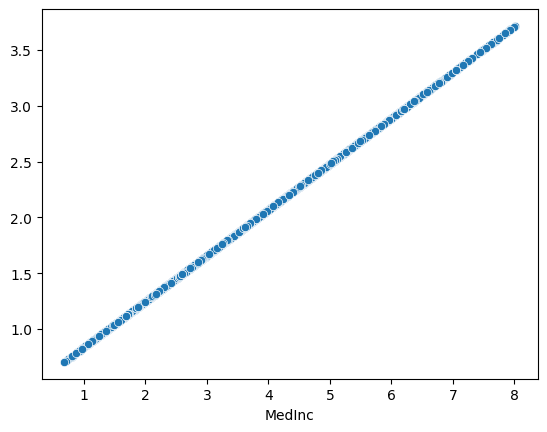

In [21]:
sns.scatterplot(x=X_test['MedInc'], y=y_pred)

* There is a strong positive linear relationship between MedInc (Median Income) and the target (Median House Value).
* The correlation heatmap showed a strong positive linear correlation between MedInc and the target, making Linear Regression a natural starting point.
* However, its results were poor (R² = 0.42), which confirms that the relationship between the features and median house value is not purely linear

In [22]:
#DecisionTreeClassifier : DecisionTreeClassifier(criterion='entropy')
#DecisionTreeClassifier : DecisionTreeClassifier(criterion='gini')
#DecisionTreeClassifier(criterion='gini',max_depth=6,min_samples_split=8,ccp_alpha=0.02,random_state=42)

# DecisionTreeRegressor(criterion="squared_error")
# DecisionTreeRegressor(criterion="friedman_mse")
# DecisionTreeRegressor(criterion="absolute_error")
#DecisionTreeRegressor(criterion="squared_error",max_depth=6,min_samples_split=8,ccp_alpha=0.02,random_state=42)
# param_grid = {
#     'max_depth': [3, 5, 7, 9],
#     'min_samples_split': [2, 5, 10],
#     'ccp_alpha': [0.0, 0.01, 0.02, 0.05]
# }
# grid = GridSearchCV(DecisionTreeRegressor(), param_grid, cv=5)



# **Regression Algorithm Implementation -- DecisionTreeRegressor**

In [23]:
X=no_outliers_df.drop('target',axis=1)
y=no_outliers_df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

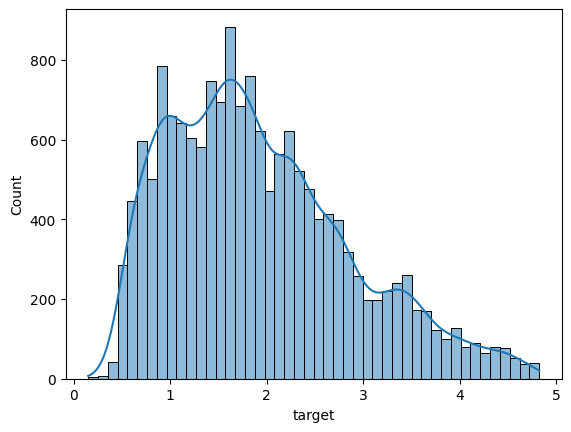

In [24]:
sns.histplot(no_outliers_df['target'], kde=True)
plt.show()

In [25]:
decisionTreeRegressor_model=DecisionTreeRegressor(criterion="squared_error")
decisionTreeRegressor_model.fit(X_train, y_train)
y_pred=decisionTreeRegressor_model.predict(X_test)
print("coefficient of determination",r2_score(y_test,y_pred))

coefficient of determination 0.5461574551720803


In [26]:
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
results.append({
"Model": "DecisionTreeReg sqr_error with out loglp '",
"R2": r2,
"MSE": mse,
"MAE": mae
})
results_df = pd.DataFrame(results)
print(results_df)

                                        Model        R2       MSE       MAE
0                          Linear Regression'  0.422856  0.504494  0.547731
1  DecisionTreeReg sqr_error with out loglp '  0.546157  0.396713  0.422397


need to improve R2  so used loglp for further tuning

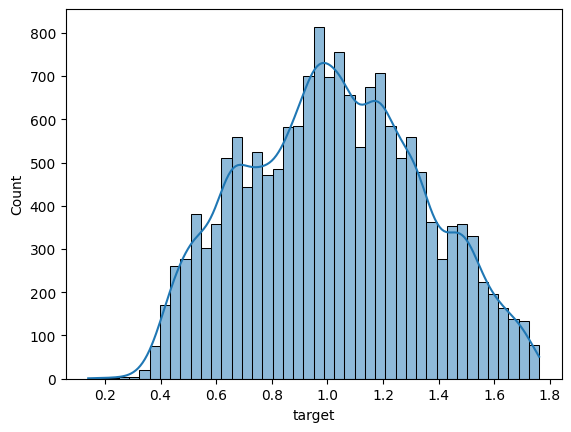

In [27]:
no_outliers_df = housing_df[within_bounds].copy()
no_outliers_df['target'] = np.log1p(no_outliers_df['target'])
sns.histplot(no_outliers_df['target'], kde=True)
plt.show()

In [28]:
X=no_outliers_df.drop(['target'],axis=1)
y=no_outliers_df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

**checking DecisionTreeRegressor​‌ squared_error**

In [29]:
decisionTreeRegressor_model=DecisionTreeRegressor(criterion="squared_error",max_depth=9,min_samples_split=2,ccp_alpha=0,random_state=42)
decisionTreeRegressor_model.fit(X_train, y_train)
y_pred=decisionTreeRegressor_model.predict(X_test)
print("coefficient of determination",r2_score(y_test,y_pred))

coefficient of determination 0.6889340152634258


In [30]:
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
results.append({
"Model": "DecisionTreeRegressor​‌ squared_error'",
"R2": r2,
"MSE": mse,
"MAE": mae
})
results_df = pd.DataFrame(results)
print(results_df)

                                        Model        R2       MSE       MAE
0                          Linear Regression'  0.422856  0.504494  0.547731
1  DecisionTreeReg sqr_error with out loglp '  0.546157  0.396713  0.422397
2      DecisionTreeRegressor​‌ squared_error'  0.688934  0.031009  0.126209


* Applied log transformation (np.log1p) to the target variable to reduce skewness.
* Trained a baseline Decision Tree Regressor using criterion='squared_error'.
* Evaluated model performance using R², MSE, and MAE.
* Tuned hyperparameters including criterion, max_depth, and min_samples_split.
* Compared multiple Decision Tree variants (squared_error, friedman_mse, and absolute_error).
* I am able to achiv achieving an R² score of 0.69 only for DecisionTreeRegressor​‌ squared_error

## **checking DecisionTreeRegressor​‌ friedman_mse **

In [31]:
decisionTreeRegressor_model=DecisionTreeRegressor(criterion="friedman_mse",max_depth=9,min_samples_split=2,ccp_alpha=0,random_state=42)
decisionTreeRegressor_model.fit(X_train, y_train)
y_pred=decisionTreeRegressor_model.predict(X_test)
print("coefficient of determination",r2_score(y_test,y_pred))

coefficient of determination 0.6856677631779113


In [32]:
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
results.append({
"Model": "DecisionTreeRegressor​‌ friedman_mse'",
"R2": r2,
"MSE": mse,
"MAE": mae
})
results_df = pd.DataFrame(results)
print(results_df)

                                        Model        R2       MSE       MAE
0                          Linear Regression'  0.422856  0.504494  0.547731
1  DecisionTreeReg sqr_error with out loglp '  0.546157  0.396713  0.422397
2      DecisionTreeRegressor​‌ squared_error'  0.688934  0.031009  0.126209
3       DecisionTreeRegressor​‌ friedman_mse'  0.685668  0.031335  0.126674


* Applied log transformation (np.log1p) to the target variable to reduce skewness.
* Trained a baseline Decision Tree Regressor using criterion='friedman_mse'.
* Evaluated model performance using R², MSE, and MAE.
* Tuned hyperparameters including criterion, max_depth, and min_samples_split.
* Compared multiple Decision Tree variants (squared_error, friedman_mse, and absolute_error).
* I am able to achiv achieving an R² score of 0.69 only for DecisionTreeRegressor​‌ friedman_mse

**checking DecisionTreeRegressor​‌ absolute_error**

In [33]:
decisionTreeRegressor_model=DecisionTreeRegressor(criterion="absolute_error",max_depth=10,min_samples_split=10,ccp_alpha=0,random_state=42)
decisionTreeRegressor_model.fit(X_train, y_train)
y_pred=decisionTreeRegressor_model.predict(X_test)
print("coefficient of determination",r2_score(y_test,y_pred))

coefficient of determination 0.7107102986911247


In [34]:
# from sklearn.tree import plot_tree
# plt.figure(figsize=(20,10))
# plot_tree(decisionTreeRegressor_model)
# plt.show()

In [35]:
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
results.append({
"Model": "DecisionTreeRegressor​‌ absolute_error'",
"R2": r2,
"MSE": mse,
"MAE": mae
})
results_df = pd.DataFrame(results)
print(results_df)

                                        Model        R2       MSE       MAE
0                          Linear Regression'  0.422856  0.504494  0.547731
1  DecisionTreeReg sqr_error with out loglp '  0.546157  0.396713  0.422397
2      DecisionTreeRegressor​‌ squared_error'  0.688934  0.031009  0.126209
3       DecisionTreeRegressor​‌ friedman_mse'  0.685668  0.031335  0.126674
4     DecisionTreeRegressor​‌ absolute_error'  0.710710  0.028838  0.119649


* Applied log transformation (np.log1p) to the target variable to reduce skewness.
* Trained a baseline Decision Tree Regressor using criterion='absolute_error'.
* Evaluated model performance using R², MSE, and MAE.
* Tuned hyperparameters including criterion, max_depth, and min_samples_split.
* Compared multiple Decision Tree variants (squared_error, friedman_mse, and absolute_error).
* I am able to achiv achieving an R² score of 0.71 only for DecisionTreeRegressor​‌ absolute_error

Decision Trees can capture non-linear relationships and feature interactions automatically

Best is absolute_error method

# **Regression Algorithm Implementation -- Random Forest Regressor**

In [36]:
RF_Regressor_model = RandomForestRegressor(random_state=42)
RF_Regressor_model.fit(X_train, y_train)
y_pred = RF_Regressor_model.predict(X_test)
print("coefficient of determination",r2_score(y_test,y_pred))

coefficient of determination 0.8261238130416069


In [37]:
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
results.append({
"Model": "Random Forest Regressor'",
"R2": r2,
"MSE": mse,
"MAE": mae
})
results_df = pd.DataFrame(results)
print(results_df)

                                        Model        R2       MSE       MAE
0                          Linear Regression'  0.422856  0.504494  0.547731
1  DecisionTreeReg sqr_error with out loglp '  0.546157  0.396713  0.422397
2      DecisionTreeRegressor​‌ squared_error'  0.688934  0.031009  0.126209
3       DecisionTreeRegressor​‌ friedman_mse'  0.685668  0.031335  0.126674
4     DecisionTreeRegressor​‌ absolute_error'  0.710710  0.028838  0.119649
5                    Random Forest Regressor'  0.826124  0.017333  0.094142


In [38]:
# RF_Regressor_model = RandomForestRegressor(n_estimators=100,random_state=42)
# RF_Regressor_model.fit(X_train, y_train)
# y_pred = RF_Regressor_model.predict(X_test)
# print("coefficient of determination",r2_score(y_test,y_pred))
# coefficient of determination 0.8261238130416069

In [39]:
# RF_Regressor_model = RandomForestRegressor(n_estimators=200,max_depth=15,min_samples_split=5,random_state=42)
# RF_Regressor_model.fit(X_train, y_train)
# y_pred = RF_Regressor_model.predict(X_test)
# print("coefficient of determination",r2_score(y_test,y_pred))
# coefficient of determination 0.8244546020734568

* It builds many trees on bootstrapped samples of the data and, at each split, considers only a random subset of features.
* It achieved the best R² score (≈ 0.826), confirming that ensemble methods are highly effective for this dataset. Its ability to model complex geographic and demographic interactions is a key strength here.

without tuning the model is performing well

# **Regression Algorithm Implementation -- Gradient Boosting Regressor**

In [40]:
GBoosting_Regressor_model = GradientBoostingRegressor(random_state=42)
GBoosting_Regressor_model.fit(X_train, y_train)
y_pred = GBoosting_Regressor_model.predict(X_test)
print("coefficient of determination",r2_score(y_test,y_pred))

coefficient of determination 0.7877040964897135


In [41]:
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
results.append({
"Model": "GBoost_Reg without loss='squared_error",
"R2": r2,
"MSE": mse,
"MAE": mae
})
results_df = pd.DataFrame(results)
print(results_df)

                                        Model        R2       MSE       MAE
0                          Linear Regression'  0.422856  0.504494  0.547731
1  DecisionTreeReg sqr_error with out loglp '  0.546157  0.396713  0.422397
2      DecisionTreeRegressor​‌ squared_error'  0.688934  0.031009  0.126209
3       DecisionTreeRegressor​‌ friedman_mse'  0.685668  0.031335  0.126674
4     DecisionTreeRegressor​‌ absolute_error'  0.710710  0.028838  0.119649
5                    Random Forest Regressor'  0.826124  0.017333  0.094142
6      GBoost_Reg without loss='squared_error  0.787704  0.021163  0.108348


In [42]:
GBoosting_Regressor_model = GradientBoostingRegressor(loss='squared_error',n_estimators=300,learning_rate=0.05,max_depth=4)
GBoosting_Regressor_model.fit(X_train, y_train)
y_pred = GBoosting_Regressor_model.predict(X_test)
print("coefficient of determination",r2_score(y_test,y_pred))


coefficient of determination 0.8253461187629989


In [43]:
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
results.append({
"Model": "GBoost_Reg with loss='squared_error",
"R2": r2,
"MSE": mse,
"MAE": mae
})
results_df = pd.DataFrame(results)
print(results_df)

                                        Model        R2       MSE       MAE
0                          Linear Regression'  0.422856  0.504494  0.547731
1  DecisionTreeReg sqr_error with out loglp '  0.546157  0.396713  0.422397
2      DecisionTreeRegressor​‌ squared_error'  0.688934  0.031009  0.126209
3       DecisionTreeRegressor​‌ friedman_mse'  0.685668  0.031335  0.126674
4     DecisionTreeRegressor​‌ absolute_error'  0.710710  0.028838  0.119649
5                    Random Forest Regressor'  0.826124  0.017333  0.094142
6      GBoost_Reg without loss='squared_error  0.787704  0.021163  0.108348
7         GBoost_Reg with loss='squared_error  0.825346  0.017411  0.096393


* Gradient Boosting builds trees sequentially, where each new tree is trained to correct the errors (residuals) of the previous ensemble
* With tuning (n_estimators=300, learning_rate=0.05, max_depth=4), it achieved R² = 0.825, nearly matching Random Forest.

# **Regression Algorithm Implementation -- Support Vector Regressor (SVR)**

In [44]:
X=no_outliers_df.drop('target',axis=1)
y=no_outliers_df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler= StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [45]:
print(X_train_scaled.shape)
print(X_test_scaled.shape)

(13049, 8)
(3263, 8)


**SVR -Linear**:

In [46]:
Linear_SVR_model = SVR(kernel='linear',C=10,gamma='auto')

use X_train_scaled   ,X_test_scaled

In [47]:
Linear_SVR_model.fit(X_train_scaled, y_train)
y_pred = Linear_SVR_model.predict(X_test_scaled)
print("coefficient of determination",r2_score(y_test,y_pred))
#coefficient of determination 0.6690989317172279

coefficient of determination 0.6690989317172279


In [48]:
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
results.append({
"Model": "Linear SVR model",
"R2": r2,
"MSE": mse,
"MAE": mae
})
results_df = pd.DataFrame(results)
print(results_df)

                                        Model        R2       MSE       MAE
0                          Linear Regression'  0.422856  0.504494  0.547731
1  DecisionTreeReg sqr_error with out loglp '  0.546157  0.396713  0.422397
2      DecisionTreeRegressor​‌ squared_error'  0.688934  0.031009  0.126209
3       DecisionTreeRegressor​‌ friedman_mse'  0.685668  0.031335  0.126674
4     DecisionTreeRegressor​‌ absolute_error'  0.710710  0.028838  0.119649
5                    Random Forest Regressor'  0.826124  0.017333  0.094142
6      GBoost_Reg without loss='squared_error  0.787704  0.021163  0.108348
7         GBoost_Reg with loss='squared_error  0.825346  0.017411  0.096393
8                            Linear SVR model  0.669099  0.032986  0.138663


use gamma= scale and try with few feature

In [49]:
Linear_SVR_model = SVR(kernel='linear',C=10,gamma='scale')

In [50]:
from sklearn.feature_selection import SelectKBest, f_regression

# select only 5 feature
selector = SelectKBest(score_func=f_regression, k=5)
X_train_few_feature = selector.fit_transform(X_train_scaled, y_train)
X_test_few_feature = selector.transform(X_test_scaled)
selected_features = X_train.columns[selector.get_support()]
print(selected_features)

Index(['MedInc', 'AveRooms', 'AveBedrms', 'AveOccup', 'Latitude'], dtype='object')


In [51]:
Linear_SVR_model.fit(X_train_few_feature, y_train)
y_pred = Linear_SVR_model.predict(X_test_few_feature)
print("coefficient of determination",r2_score(y_test,y_pred))
#coefficient of determination 0.5686278731779357

coefficient of determination 0.5686278731779357


In [52]:
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
results.append({
"Model": "Linear SVR model with 5 feature",
"R2": r2,
"MSE": mse,
"MAE": mae
})
results_df = pd.DataFrame(results)
print(results_df)

                                        Model        R2       MSE       MAE
0                          Linear Regression'  0.422856  0.504494  0.547731
1  DecisionTreeReg sqr_error with out loglp '  0.546157  0.396713  0.422397
2      DecisionTreeRegressor​‌ squared_error'  0.688934  0.031009  0.126209
3       DecisionTreeRegressor​‌ friedman_mse'  0.685668  0.031335  0.126674
4     DecisionTreeRegressor​‌ absolute_error'  0.710710  0.028838  0.119649
5                    Random Forest Regressor'  0.826124  0.017333  0.094142
6      GBoost_Reg without loss='squared_error  0.787704  0.021163  0.108348
7         GBoost_Reg with loss='squared_error  0.825346  0.017411  0.096393
8                            Linear SVR model  0.669099  0.032986  0.138663
9             Linear SVR model with 5 feature  0.568628  0.043002  0.160278


**SVR -RBF**:

In [53]:
rbf_SVR_model = SVR(kernel='rbf',C=10,gamma='auto')

In [54]:
rbf_SVR_model.fit(X_train_scaled, y_train)
y_pred = rbf_SVR_model.predict(X_test_scaled)
print("coefficient of determination",r2_score(y_test,y_pred))
#coefficient of determination 0.7784800215667713

coefficient of determination 0.7784800215667713


In [55]:
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
results.append({
"Model": "SVR -rbf",
"R2": r2,
"MSE": mse,
"MAE": mae
})
results_df = pd.DataFrame(results)
print(results_df)

                                         Model        R2       MSE       MAE
0                           Linear Regression'  0.422856  0.504494  0.547731
1   DecisionTreeReg sqr_error with out loglp '  0.546157  0.396713  0.422397
2       DecisionTreeRegressor​‌ squared_error'  0.688934  0.031009  0.126209
3        DecisionTreeRegressor​‌ friedman_mse'  0.685668  0.031335  0.126674
4      DecisionTreeRegressor​‌ absolute_error'  0.710710  0.028838  0.119649
5                     Random Forest Regressor'  0.826124  0.017333  0.094142
6       GBoost_Reg without loss='squared_error  0.787704  0.021163  0.108348
7          GBoost_Reg with loss='squared_error  0.825346  0.017411  0.096393
8                             Linear SVR model  0.669099  0.032986  0.138663
9              Linear SVR model with 5 feature  0.568628  0.043002  0.160278
10                                    SVR -rbf  0.778480  0.022083  0.110659


**SVR -Poly**:

In [56]:
poly_SVR_model = SVR(kernel='poly',C=10,gamma='auto')

In [57]:
poly_SVR_model.fit(X_train_scaled, y_train)
y_pred = poly_SVR_model.predict(X_test_scaled)
print("coefficient of determination",r2_score(y_test,y_pred))
#coefficient of determination 0.5616597594697906

coefficient of determination 0.5616597594697906


In [58]:
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
results.append({
"Model": "SVR -poly",
"R2": r2,
"MSE": mse,
"MAE": mae
})
results_df = pd.DataFrame(results)
print(results_df)

                                         Model        R2       MSE       MAE
0                           Linear Regression'  0.422856  0.504494  0.547731
1   DecisionTreeReg sqr_error with out loglp '  0.546157  0.396713  0.422397
2       DecisionTreeRegressor​‌ squared_error'  0.688934  0.031009  0.126209
3        DecisionTreeRegressor​‌ friedman_mse'  0.685668  0.031335  0.126674
4      DecisionTreeRegressor​‌ absolute_error'  0.710710  0.028838  0.119649
5                     Random Forest Regressor'  0.826124  0.017333  0.094142
6       GBoost_Reg without loss='squared_error  0.787704  0.021163  0.108348
7          GBoost_Reg with loss='squared_error  0.825346  0.017411  0.096393
8                             Linear SVR model  0.669099  0.032986  0.138663
9              Linear SVR model with 5 feature  0.568628  0.043002  0.160278
10                                    SVR -rbf  0.778480  0.022083  0.110659
11                                   SVR -poly  0.561660  0.043697  0.157622

**SVR -Sigmoid**:

In [59]:
sigmoid_SVR_model = SVR(kernel='sigmoid',C=100,gamma=0.001,epsilon=0.1)

In [60]:
sigmoid_SVR_model.fit(X_train_scaled, y_train)
y_pred = sigmoid_SVR_model.predict(X_test_scaled)
print("coefficient of determination",r2_score(y_test,y_pred))

coefficient of determination 0.6681824263849543


In [61]:
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
results.append({
"Model": "SVR -sigmoid",
"R2": r2,
"MSE": mse,
"MAE": mae
})
results_df = pd.DataFrame(results)
print(results_df)

                                         Model        R2       MSE       MAE
0                           Linear Regression'  0.422856  0.504494  0.547731
1   DecisionTreeReg sqr_error with out loglp '  0.546157  0.396713  0.422397
2       DecisionTreeRegressor​‌ squared_error'  0.688934  0.031009  0.126209
3        DecisionTreeRegressor​‌ friedman_mse'  0.685668  0.031335  0.126674
4      DecisionTreeRegressor​‌ absolute_error'  0.710710  0.028838  0.119649
5                     Random Forest Regressor'  0.826124  0.017333  0.094142
6       GBoost_Reg without loss='squared_error  0.787704  0.021163  0.108348
7          GBoost_Reg with loss='squared_error  0.825346  0.017411  0.096393
8                             Linear SVR model  0.669099  0.032986  0.138663
9              Linear SVR model with 5 feature  0.568628  0.043002  0.160278
10                                    SVR -rbf  0.778480  0.022083  0.110659
11                                   SVR -poly  0.561660  0.043697  0.157622

* SVR finds a hyperplane  that fits the data within a margin of tolerance
it ignores errors and penalizes larger errors
* Linear kernel: fits a straight hyperplane.
* RBF  kernel: maps data into infinite-dimensional space, capturing complex non-linearities.
* Poly kernel: uses polynomial transformations.
* Sigmoid kernel: behaves like a neural network activation
* The RBF kernel performed best (R² ≈ 0.778), showing it can capture non-linear patterns effectively.


In [62]:
results_df["RMSE"] = np.sqrt(results_df["MSE"])

results_df = results_df.round(4)

display(
    results_df[
        ["Model", "R2", "MAE", "RMSE", "MSE"]
    ].sort_values(
        "R2",
        ascending=False
    ).reset_index(drop=True)
)

,Model,R2,MAE,RMSE,MSE
0,Random Forest Regressor',0.8261,0.0941,0.1317,0.0173
1,GBoost_Reg with loss='squared_error,0.8253,0.0964,0.1319,0.0174
2,GBoost_Reg without loss='squared_error,0.7877,0.1083,0.1455,0.0212
3,SVR -rbf,0.7785,0.1107,0.1486,0.0221
4,DecisionTreeRegressor​‌ absolute_error',0.7107,0.1196,0.1698,0.0288
5,DecisionTreeRegressor​‌ squared_error',0.6889,0.1262,0.1761,0.0310
6,DecisionTreeRegressor​‌ friedman_mse',0.6857,0.1267,0.1770,0.0313
7,Linear SVR model,0.6691,0.1387,0.1816,0.0330
8,SVR -sigmoid,0.6682,0.1389,0.1819,0.0331
9,Linear SVR model with 5 feature,0.5686,0.1603,0.2074,0.0430


* Linear Regression	0.423	Poor — assumes linearity, which the data violates.
* Decision Tree (absolute_error)	0.711	Good — captures non-linearity, but overfits alone.
* Random Forest	0.826	Excellent — best overall; handles non-linearity and interactions.
* Gradient Boosting (tuned)	0.825	Excellent — nearly matches Random Forest with tuning.
* SVR (RBF)	0.778	Good — handles non-linearity but is computationally expensive and sensitive to scaling.
* SVR (Linear)	0.669	Moderate — limited by linear assumption.
* SVR (Poly/Sigmoid)	0.56–0.67	Weak

In [63]:
new_data = pd.DataFrame([
    [8.3252, 41.0, 6.98, 1.02, 322.0, 2.55, 37.88, -122.23],
   [1.7000, 17.0, 5.20, 1.10, 1200.0, 2.32, 39.43, -121.22],
    [2.3886, 16.0, 5.25,	1.16,	1387.0,	2.62,	39.37,	-121.24	],
    [5.6431, 52.0, 5.81, 1.07, 558.0, 2.54, 37.85, -122.25],
], columns=X.columns)

In [64]:
predictions = RF_Regressor_model.predict(new_data)

In [65]:
original_predictions = np.expm1(predictions)  # Convert back to the original scale
print(original_predictions)

[3.77783914 0.84729786 0.91028142 3.41242025]


In [66]:
housing_df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847
